# Data Augmentation on MNIST Dataset (GPU-Accelerated)

This notebook demonstrates image data augmentation techniques on the MNIST dataset using Python, TensorFlow (GPU version), and the `imgaug` library. The MNIST dataset contains 28x28 grayscale images of handwritten digits. Each augmentation technique is implemented in a separate cell for clarity, and all prerequisites are installed within the notebook. The code is optimized to run on a GPU for faster computation, especially for the GAN training.

The following augmentation techniques are covered:
- Rotation
- Scaling/Zooming
- Cropping
- Flipping
- Brightness/Contrast Adjustment
- Noise Injection
- Intensity Jittering (adapted for grayscale)
- Geometric Distortion
- Shear
- Synthetic Image Generation (using a simple GAN)

## Prerequisites
The notebook includes installation commands for all required libraries. If running locally, ensure you have an NVIDIA GPU with CUDA 12.2 and cuDNN installed. In Google Colab, GPU support is available by default (select 'GPU' in Runtime > Change runtime type).

In [4]:
# Load necessary libraries and prepare sample image from MNIST

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import mnist

# Load the MNIST dataset
(x_train, y_train), _ = mnist.load_data()

# Normalize the images to [0, 1]
x_train = x_train.astype('float32') / 255.0

# Expand dimensions to add channel (for grayscale images)
x_train = np.expand_dims(x_train, axis=-1)  # Shape becomes (28, 28, 1)

# Select a sample image from the training set
sample_image = x_train[0]

# Function to show a list of images
def show_images(images, title="Augmented Images"):
    plt.figure(figsize=(12, 2))
    for i, img in enumerate(images):
        plt.subplot(1, len(images), i + 1)
        plt.imshow(img.squeeze(), cmap='gray')
        plt.axis('off')
    plt.suptitle(title)
    plt.show()


## Rotation (Image Rotation)

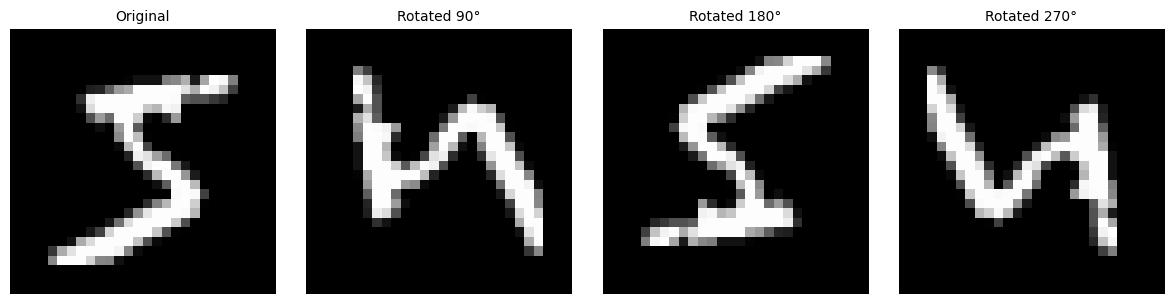

In [7]:
# Rotate the image using tf.image.rot90 at 90, 180, and 270 degrees

# Perform fixed-angle rotations
rotated_90 = tf.image.rot90(sample_image, k=1).numpy()   # Rotate 90 degrees counter-clockwise
rotated_180 = tf.image.rot90(sample_image, k=2).numpy()  # Rotate 180 degrees
rotated_270 = tf.image.rot90(sample_image, k=3).numpy()  # Rotate 270 degrees

# Combine all images for display
all_images = [sample_image, rotated_90, rotated_180, rotated_270]
labels = ["Original", "Rotated 90°", "Rotated 180°", "Rotated 270°"]

# Display images with corresponding labels
plt.figure(figsize=(12, 3))
for i, (img, label) in enumerate(zip(all_images, labels)):
    plt.subplot(1, len(all_images), i + 1)
    plt.imshow(img.squeeze(), cmap='gray')
    plt.title(label, fontsize=10)
    plt.axis('off')
plt.tight_layout()
plt.show()


## Cell 3: Scaling / Zooming

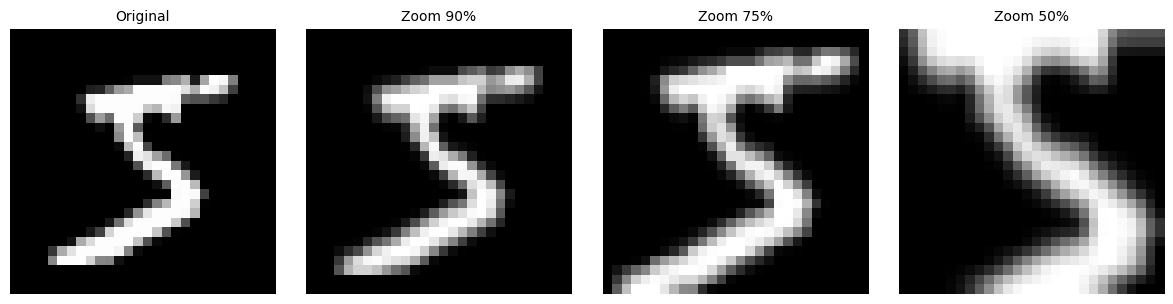

In [8]:
# Apply scaling (zoom in) by cropping the center and resizing back to original size

# Define zoom factors (smaller crop => more zoom)
zoom_factors = [0.9, 0.75, 0.5]

# Generate zoomed images by cropping and resizing
zoomed_images = []
for factor in zoom_factors:
    cropped = tf.image.central_crop(sample_image, central_fraction=factor)  # crop center
    resized = tf.image.resize(cropped, (28, 28)).numpy()                    # resize back to 28x28
    zoomed_images.append(resized)

# Labels for display
labels = [f"Zoom {int(f*100)}%" for f in zoom_factors]

# Display original + zoomed images
plt.figure(figsize=(12, 3))
plt.subplot(1, len(zoomed_images) + 1, 1)
plt.imshow(sample_image.squeeze(), cmap='gray')
plt.title("Original", fontsize=10)
plt.axis('off')

for i, (img, label) in enumerate(zip(zoomed_images, labels)):
    plt.subplot(1, len(zoomed_images) + 1, i + 2)
    plt.imshow(img.squeeze(), cmap='gray')
    plt.title(label, fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()


## Cell 4: Random Cropping

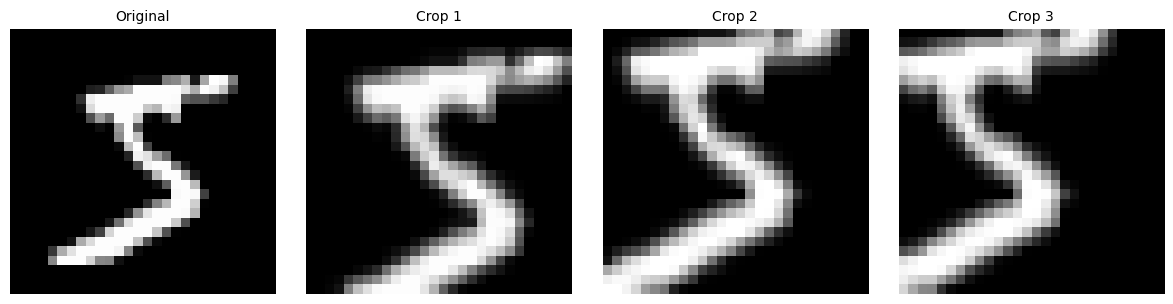

In [9]:
# Apply random cropping to simulate focusing on different parts of the image

# Set random seed for reproducibility
seed = 42
cropped_images = []

# Perform 3 different random crops followed by resizing to original size
for i in range(3):
    cropped = tf.image.stateless_random_crop(
        sample_image,
        size=[20, 20, 1],
        seed=[seed, i]  # use different seed each time
    )
    resized = tf.image.resize(cropped, (28, 28)).numpy()
    cropped_images.append(resized)

# Display the original and randomly cropped-resized images
plt.figure(figsize=(12, 3))
plt.subplot(1, 4, 1)
plt.imshow(sample_image.squeeze(), cmap='gray')
plt.title("Original", fontsize=10)
plt.axis('off')

for i, img in enumerate(cropped_images):
    plt.subplot(1, 4, i + 2)
    plt.imshow(img.squeeze(), cmap='gray')
    plt.title(f"Crop {i+1}", fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()


## Cell 5: Flipping (Horizontal and Vertical Flip)

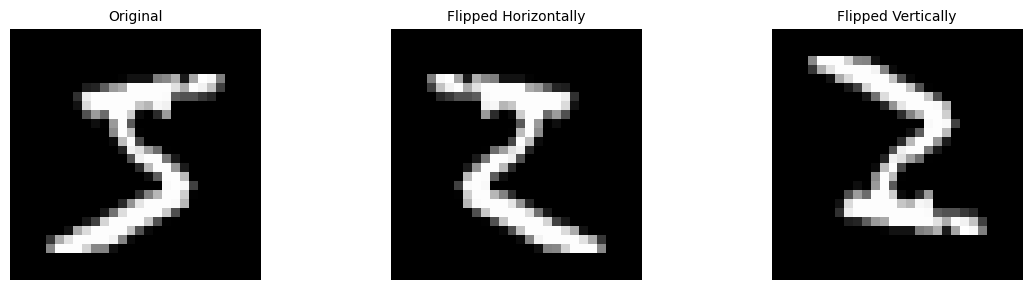

In [10]:
# Apply horizontal and vertical flipping

# Flip the image horizontally (left-right)
flipped_horizontal = tf.image.flip_left_right(sample_image).numpy()

# Flip the image vertically (up-down)
flipped_vertical = tf.image.flip_up_down(sample_image).numpy()

# Display the original and flipped versions
images = [sample_image, flipped_horizontal, flipped_vertical]
labels = ["Original", "Flipped Horizontally", "Flipped Vertically"]

plt.figure(figsize=(12, 3))
for i, (img, label) in enumerate(zip(images, labels)):
    plt.subplot(1, 3, i + 1)
    plt.imshow(img.squeeze(), cmap='gray')
    plt.title(label, fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()


## Cell 6: Brightness / Contrast Adjustment

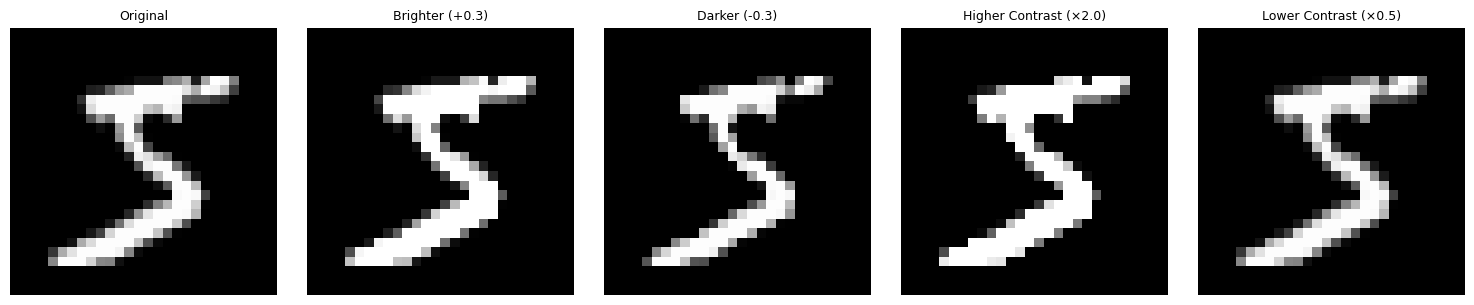

In [11]:
# Apply brightness and contrast adjustment

# Increase and decrease brightness
brighter = tf.image.adjust_brightness(sample_image, delta=0.3).numpy()
darker = tf.image.adjust_brightness(sample_image, delta=-0.3).numpy()

# Increase and decrease contrast
higher_contrast = tf.image.adjust_contrast(sample_image, contrast_factor=2.0).numpy()
lower_contrast = tf.image.adjust_contrast(sample_image, contrast_factor=0.5).numpy()

# List of all images and labels
images = [sample_image, brighter, darker, higher_contrast, lower_contrast]
labels = [
    "Original",
    "Brighter (+0.3)",
    "Darker (-0.3)",
    "Higher Contrast (×2.0)",
    "Lower Contrast (×0.5)"
]

# Display images with titles
plt.figure(figsize=(15, 3))
for i, (img, label) in enumerate(zip(images, labels)):
    plt.subplot(1, len(images), i + 1)
    plt.imshow(np.clip(img.squeeze(), 0, 1), cmap='gray')  # ensure values stay in [0,1]
    plt.title(label, fontsize=9)
    plt.axis('off')

plt.tight_layout()
plt.show()


## Cell 7: Noise Injection (Gaussian Noise)

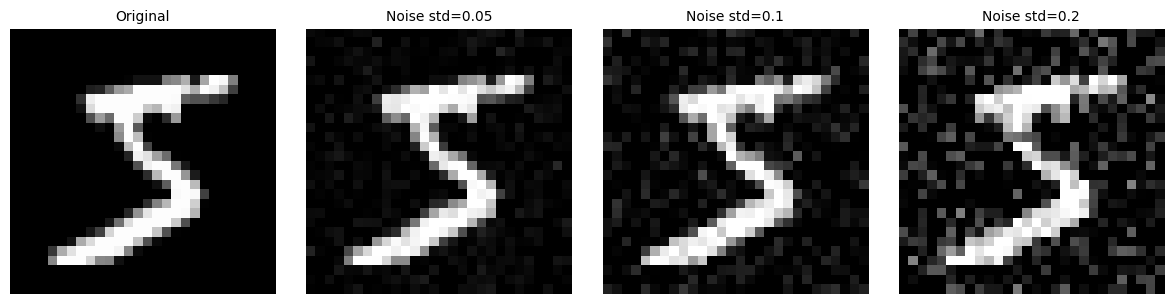

In [12]:
# Apply Gaussian noise to the image

# Define function to add Gaussian noise
def add_gaussian_noise(image, stddev):
    noise = tf.random.normal(shape=image.shape, mean=0.0, stddev=stddev, dtype=tf.float32)
    noisy_image = image + noise
    return tf.clip_by_value(noisy_image, 0.0, 1.0).numpy()  # keep values in [0, 1]

# Generate noisy images with different levels of noise
noisy_1 = add_gaussian_noise(sample_image, stddev=0.05)
noisy_2 = add_gaussian_noise(sample_image, stddev=0.1)
noisy_3 = add_gaussian_noise(sample_image, stddev=0.2)

# Display original and noisy versions
images = [sample_image, noisy_1, noisy_2, noisy_3]
labels = ["Original", "Noise std=0.05", "Noise std=0.1", "Noise std=0.2"]

plt.figure(figsize=(12, 3))
for i, (img, label) in enumerate(zip(images, labels)):
    plt.subplot(1, len(images), i + 1)
    plt.imshow(img.squeeze(), cmap='gray')
    plt.title(label, fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()


## Cell 8: Shear Transform

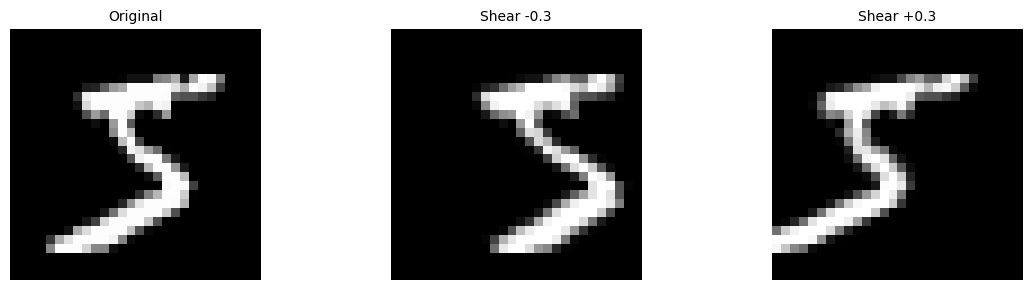

In [13]:
# Apply shear transformation (horizontal skew)

def shear_image(image, shear_level):
    # Define affine transformation matrix for horizontal shear
    transform = [1.0, shear_level, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0]  # shape: [8]
    image = tf.convert_to_tensor(image[None, ...])  # Add batch dimension

    # Apply the projective transform
    sheared = tf.raw_ops.ImageProjectiveTransformV2(
        images=image,
        transforms=[transform],
        output_shape=[28, 28],
        interpolation="BILINEAR"
    )
    return tf.squeeze(sheared).numpy()  # Remove batch dimension

# Generate sheared images with different shear levels
shear_neg = shear_image(sample_image, shear_level=-0.3)
shear_pos = shear_image(sample_image, shear_level=0.3)

# Display the original and sheared images
images = [sample_image, shear_neg, shear_pos]
labels = ["Original", "Shear -0.3", "Shear +0.3"]

plt.figure(figsize=(12, 3))
for i, (img, label) in enumerate(zip(images, labels)):
    plt.subplot(1, 3, i + 1)
    plt.imshow(img.squeeze(), cmap='gray')
    plt.title(label, fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()


## Cell 9: Geometric Distortion (Elastic-like Warping)

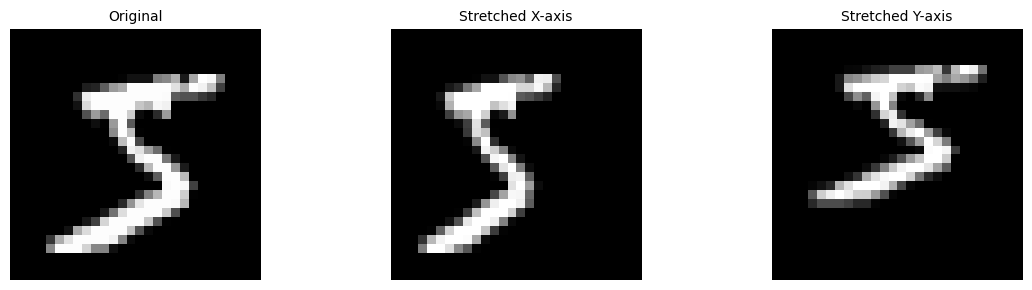

In [15]:
# Apply simple geometric distortion using affine transformation

def distort_image(image, scale_x=1.0, scale_y=1.0):
    # Create an affine transformation matrix for scaling in x and y
    transform = [scale_x, 0.0, 0.0, 0.0, scale_y, 0.0, 0.0, 0.0]
    image = tf.convert_to_tensor(image[None, ...])  # Add batch dimension

    distorted = tf.raw_ops.ImageProjectiveTransformV2(
        images=image,
        transforms=[transform],
        output_shape=[28, 28],
        interpolation="BILINEAR"
    )
    return tf.squeeze(distorted).numpy()

# Generate distorted images
stretch_x = distort_image(sample_image, scale_x=1.3, scale_y=1.0)
stretch_y = distort_image(sample_image, scale_x=1.0, scale_y=1.3)

# Display results
images = [sample_image, stretch_x, stretch_y]
labels = ["Original", "Stretched X-axis", "Stretched Y-axis"]

plt.figure(figsize=(12, 3))
for i, (img, label) in enumerate(zip(images, labels)):
    plt.subplot(1, 3, i + 1)
    plt.imshow(img.squeeze(), cmap='gray')
    plt.title(label, fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()


## Cell 10: Synthetic Image Generation

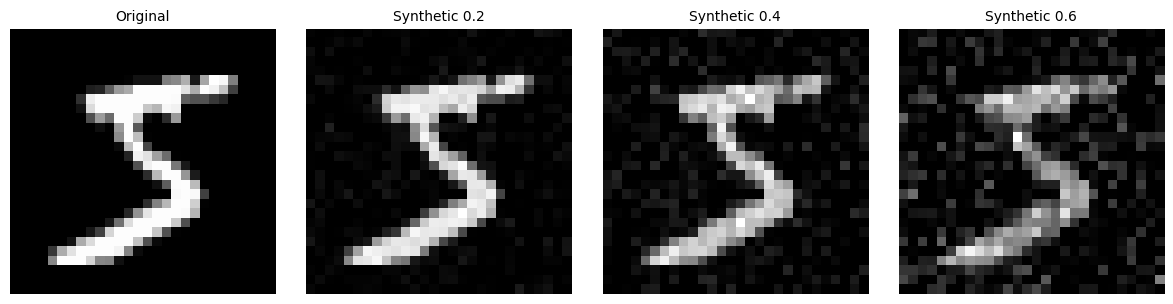

In [16]:
# Create synthetic-like images by blending original with variations

def generate_synthetic_variants(image, factor):
    # Add slight noise and blend with original
    noise = tf.random.normal(image.shape, mean=0.0, stddev=0.15)
    synthetic = (1 - factor) * image + factor * noise
    return tf.clip_by_value(synthetic, 0.0, 1.0).numpy()

# Generate synthetic variants
synth_1 = generate_synthetic_variants(sample_image, factor=0.2)
synth_2 = generate_synthetic_variants(sample_image, factor=0.4)
synth_3 = generate_synthetic_variants(sample_image, factor=0.6)

# Display original and synthetic images
images = [sample_image, synth_1, synth_2, synth_3]
labels = ["Original", "Synthetic 0.2", "Synthetic 0.4", "Synthetic 0.6"]

plt.figure(figsize=(12, 3))
for i, (img, label) in enumerate(zip(images, labels)):
    plt.subplot(1, len(images), i + 1)
    plt.imshow(img.squeeze(), cmap='gray')
    plt.title(label, fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()


## Cell Title: Image Augmentation using Albumentations

C:\Users\ASUS\AppData\Local\Temp\ipykernel_16200\721376484.py:24: DeprecationWarning: Flip is deprecated. Consider using HorizontalFlip, VerticalFlip, RandomRotate90 or D4.
  A.Flip(),  # horizontal or vertical flip


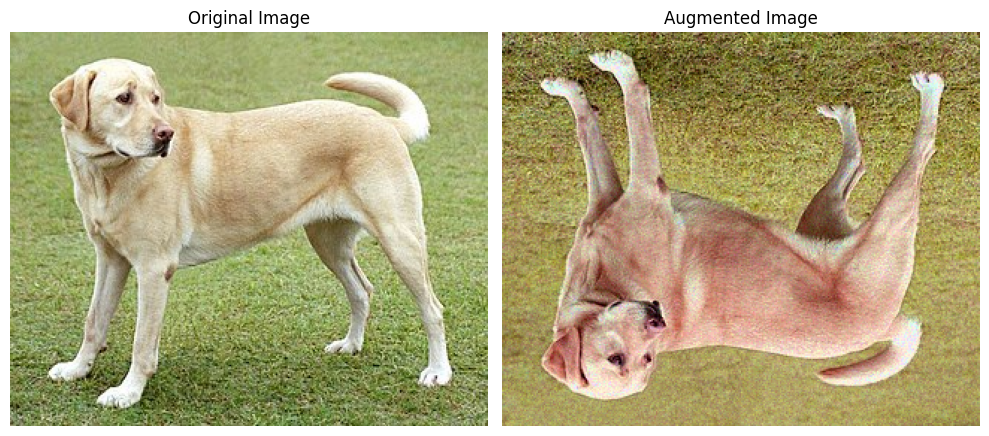

In [6]:
# Install Albumentations and OpenCV if not already installed
# !pip install albumentations opencv-python matplotlib

import cv2
import urllib.request
import matplotlib.pyplot as plt
import albumentations as A
from albumentations.pytorch import ToTensorV2

# Step 1: Download a sample image
url = "https://upload.wikimedia.org/wikipedia/commons/thumb/2/26/YellowLabradorLooking_new.jpg/320px-YellowLabradorLooking_new.jpg"
image_path = "sample.jpg"
urllib.request.urlretrieve(url, image_path)

# Step 2: Read and convert the image
image = cv2.imread(image_path)
if image is None:
    raise ValueError("Failed to load the image.")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Step 3: Define augmentation pipeline
transform = A.Compose([
    A.RandomRotate90(),
    A.Flip(),  # horizontal or vertical flip
    A.RandomBrightnessContrast(p=0.2),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=15, p=0.5),
    A.GaussNoise(p=0.2),
    A.HueSaturationValue(p=0.3),
])

# Step 4: Apply augmentation
augmented = transform(image=image)
augmented_image = augmented['image']

# Step 5: Display original and augmented images
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(augmented_image)
plt.title('Augmented Image')
plt.axis('off')

plt.tight_layout()
plt.show()


# Text Data Augmentation

## Cell 1: Synonym Replacement

In [17]:
# Install NLTK if not already installed
!pip install -q nltk

# Download WordNet data
import nltk
nltk.download('wordnet')
nltk.download('omw-1.4')


[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...


True

In [18]:
import random
from nltk.corpus import wordnet

# Function to get synonyms from WordNet
def get_synonyms(word):
    synonyms = set()
    for syn in wordnet.synsets(word):
        for lemma in syn.lemmas():
            # Avoid returning the word itself
            if lemma.name().lower() != word.lower():
                synonyms.add(lemma.name().replace('_', ' '))
    return list(synonyms)

# Function to randomly replace words with synonyms
def synonym_replacement(sentence, n=1):
    words = sentence.split()
    new_words = words.copy()
    random_word_list = list(set([word for word in words if get_synonyms(word)]))
    random.shuffle(random_word_list)

    num_replaced = 0
    for word in random_word_list:
        synonyms = get_synonyms(word)
        if synonyms:
            synonym = random.choice(synonyms)
            new_words = [synonym if w == word else w for w in new_words]
            num_replaced += 1
        if num_replaced >= n:
            break

    return ' '.join(new_words)

# Example
original_text = "The quick brown fox jumps over the lazy dog"
augmented_text = synonym_replacement(original_text, n=2)

print("Original:", original_text)
print("Augmented:", augmented_text)


Original: The quick brown fox jumps over the lazy dog
Augmented: The flying Robert Brown fox jumps over the lazy dog


## Cell 2: Random Deletion

In [22]:
import random

# Function to randomly delete words from a sentence
def random_deletion(sentence, p=0.2):
    """
    Randomly deletes words from the sentence with probability p.
    """
    words = sentence.split()
    if len(words) == 1:
        return sentence  # Skip if only one word

    new_words = []
    for word in words:
        r = random.uniform(0, 1)
        if r > p:
            new_words.append(word)

    # Ensure at least one word remains
    if len(new_words) == 0:
        new_words.append(random.choice(words))

    return ' '.join(new_words)

# Example
original_text = "The quick brown fox jumps over the lazy dog"
augmented_text = random_deletion(original_text, p=0.3)

# Explanation printed as part of the output
print("=== Random Deletion ===")
print("This technique randomly removes words from the sentence with a given probability (p).")
print("It helps simulate incomplete or noisy text data, which improves model robustness.")
print("Probability of deletion used in this example: p = 0.2")
print()

# Output
print("Original:", original_text)
print("Augmented:", augmented_text)


=== Random Deletion ===
This technique randomly removes words from the sentence with a given probability (p).
It helps simulate incomplete or noisy text data, which improves model robustness.
Probability of deletion used in this example: p = 0.3

Original: The quick brown fox jumps over the lazy dog
Augmented: The quick brown over the lazy


## Cell 3: Random Swap

In [23]:
import random

# Function to randomly swap two words in the sentence n times
def random_swap(sentence, n=2):
    """
    Randomly swaps two words in the sentence n times.
    """
    words = sentence.split()
    length = len(words)
    if length < 2:
        return sentence

    for _ in range(n):
        idx1, idx2 = random.sample(range(length), 2)
        words[idx1], words[idx2] = words[idx2], words[idx1]

    return ' '.join(words)

# Example
original_text = "The quick brown fox jumps over the lazy dog"
augmented_text = random_swap(original_text, n=3)

# Explanation printed as part of the output
print("=== Random Swap ===")
print("This technique randomly swaps two words in the sentence a specified number of times (n).")
print("It creates structural variety in the sentence while keeping the content mostly intact.")
print("Number of swaps in this example: n = 3")
print()

# Output
print("Original:", original_text)
print("Augmented:", augmented_text)


=== Random Swap ===
This technique randomly swaps two words in the sentence a specified number of times (n).
It creates structural variety in the sentence while keeping the content mostly intact.
Number of swaps in this example: n = 3

Original: The quick brown fox jumps over the lazy dog
Augmented: jumps quick brown lazy The fox the over dog


## Cell 4: Random Insertion 

In [25]:
import nltk
from nltk.corpus import wordnet
nltk.download('wordnet')
nltk.download('omw-1.4')

import random

# Function to get synonyms for a given word
def get_synonyms(word):
    synonyms = set()
    for syn in wordnet.synsets(word):
        for lemma in syn.lemmas():
            synonym = lemma.name().replace('_', ' ').lower()
            if synonym != word.lower():
                synonyms.add(synonym)
    return list(synonyms)

# Function to insert n random synonyms into the sentence
def random_insertion(sentence, n=2):
    """
    Randomly inserts n synonyms of random words into the sentence.
    """
    words = sentence.split()
    for _ in range(n):
        new_word = None
        counter = 0
        while new_word is None and counter < 10:
            random_word = random.choice(words)
            synonyms = get_synonyms(random_word)
            if synonyms:
                new_word = random.choice(synonyms)
            counter += 1
        if new_word:
            insert_position = random.randint(0, len(words))
            words.insert(insert_position, new_word)
    return ' '.join(words)

# Example
original_text = "The quick brown fox jumps over the lazy dog"
augmented_text = random_insertion(original_text, n=2)

# Explanation
print("=== Random Insertion ===")
print("This technique inserts n synonyms of randomly selected words into the sentence.")
print("It helps increase sentence length and introduce new, related vocabulary.")
print("Number of insertions in this example: n = 2")
print()

# Output
print("Original:", original_text)
print("Augmented:", augmented_text)


=== Random Insertion ===
This technique inserts n synonyms of randomly selected words into the sentence.
It helps increase sentence length and introduce new, related vocabulary.
Number of insertions in this example: n = 2

Original: The quick brown fox jumps over the lazy dog
Augmented: The quick brown fox jumps robert brown over pull a fast one on the lazy dog


[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


## Cell 5: Random Deletion 

In [30]:
import random

# Function to randomly delete words from a sentence with probability p
def random_deletion(sentence, p=0.2):
    """
    Randomly deletes words from the sentence with probability p.
    Useful for simulating incomplete or noisy text.
    """
    words = sentence.split()
    if len(words) == 1:
        return sentence  # Do not delete if only one word
    remaining_words = [word for word in words if random.uniform(0, 1) > p]
    if not remaining_words:
        # ensure at least one word remains
        remaining_words = [random.choice(words)]
    return ' '.join(remaining_words)

# Example
original_text = "The quick brown fox jumps over the lazy dog"
augmented_text = random_deletion(original_text, p=0.2)

# Explanation
print("=== Random Deletion ===")
print("This technique randomly deletes each word in the sentence with a fixed probability p.")
print("It is useful for simulating noise, incomplete data, or missing words.")
print("Deletion probability in this example: p = 0.2")
print()

# Output
print("Original:", original_text)
print("Augmented:", augmented_text)


=== Random Deletion ===
This technique randomly deletes each word in the sentence with a fixed probability p.
It is useful for simulating noise, incomplete data, or missing words.
Deletion probability in this example: p = 0.2

Original: The quick brown fox jumps over the lazy dog
Augmented: quick brown fox jumps the lazy dog


## Cell 6: Paraphrasing using Pretrained Language Models

In [4]:
from transformers import T5Tokenizer, T5ForConditionalGeneration
import torch

# Load tokenizer with use_fast=False to ensure sentencepiece compatibility
tokenizer = T5Tokenizer.from_pretrained("Vamsi/T5_Paraphrase_Paws", use_fast=False)

# Load the T5 model
model = T5ForConditionalGeneration.from_pretrained("Vamsi/T5_Paraphrase_Paws")

# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# Function to generate multiple paraphrases
def paraphrase_text(text, num_return_sequences=5):
    input_text = f"paraphrase: {text} </s>"
    encoding = tokenizer.encode_plus(
        input_text,
        padding="max_length",
        max_length=128,
        return_tensors="pt",
        truncation=True
    )
    input_ids = encoding["input_ids"].to(device)
    attention_mask = encoding["attention_mask"].to(device)

    outputs = model.generate(
        input_ids=input_ids,
        attention_mask=attention_mask,
        max_length=256,
        do_sample=True,        # Enables random sampling
        top_k=120,             # Filters to top-k tokens
        top_p=0.95,            # Nucleus sampling
        temperature=1.0,       # Adds randomness
        num_return_sequences=num_return_sequences
    )

    return [tokenizer.decode(output, skip_special_tokens=True) for output in outputs]

# Example input
original = "Learning from failures is often more valuable than learning from success."

# Generate and print paraphrases
paraphrased_outputs = paraphrase_text(original, num_return_sequences=5)

print("Original:", original)
print("Paraphrased versions:")
for i, sentence in enumerate(paraphrased_outputs, 1):
    print(f"{i}. {sentence}")


Original: Learning from failures is often more valuable than learning from success.
Paraphrased versions:
1. Learning from failures is often more valuable than learning from success.
2. Learning from failures is often more valuable than learning from success.
3. Learning from failures is often more valuable than learning from success.
4. Learning from failures is often more valuable than learning from success.
5. Learning from failures is often more valuable than learning from success.


In [5]:
from transformers import T5Tokenizer, T5ForConditionalGeneration
import torch

# Load better paraphrasing model
model_name = "ramsrigouthamg/t5_paraphraser"
tokenizer = T5Tokenizer.from_pretrained(model_name, use_fast=False)
model = T5ForConditionalGeneration.from_pretrained(model_name)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

def paraphrase_text(text, num_return_sequences=5):
    input_text = f"paraphrase: {text} </s>"
    encoding = tokenizer.encode_plus(
        input_text,
        padding="max_length",
        max_length=128,
        return_tensors="pt",
        truncation=True
    )
    input_ids = encoding["input_ids"].to(device)
    attention_mask = encoding["attention_mask"].to(device)

    outputs = model.generate(
        input_ids=input_ids,
        attention_mask=attention_mask,
        max_length=256,
        do_sample=True,
        top_k=120,
        top_p=0.95,
        temperature=1.2,
        num_return_sequences=num_return_sequences
    )

    return [tokenizer.decode(output, skip_special_tokens=True) for output in outputs]

# Example usage
original = "Learning from failures is often more valuable than learning from success."
paraphrased_outputs = paraphrase_text(original)

print("Original:", original)
print("Paraphrased versions:")
for i, sentence in enumerate(paraphrased_outputs, 1):
    print(f"{i}. {sentence}")


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/892M [00:00<?, ?B/s]

Original: Learning from failures is often more valuable than learning from success.
Paraphrased versions:
1. Learning from failure is always more valuable than learning from failure alone.
2. Does learning from failures count as much as it does from the experience of others?
3. Learn from failure or success.
4. Learning from failures is often more valuable than learning from success.
5. Much more valuable than learning from failure.


## Back-Translation

In [1]:
from transformers import MarianTokenizer, MarianMTModel

# Define a function to perform back translation using MarianMT
def back_translate(text, src_lang="en", pivot_lang="fr"):
    # Translate from source language to pivot language (e.g. English → French)
    model_name_src2pivot = f'Helsinki-NLP/opus-mt-{src_lang}-{pivot_lang}'
    tokenizer_src2pivot = MarianTokenizer.from_pretrained(model_name_src2pivot)
    model_src2pivot = MarianMTModel.from_pretrained(model_name_src2pivot)
    
    encoded = tokenizer_src2pivot(text, return_tensors="pt", padding=True)
    translated = model_src2pivot.generate(**encoded)
    pivot_text = tokenizer_src2pivot.decode(translated[0], skip_special_tokens=True)

    # Translate back from pivot language to source language (e.g. French → English)
    model_name_pivot2src = f'Helsinki-NLP/opus-mt-{pivot_lang}-{src_lang}'
    tokenizer_pivot2src = MarianTokenizer.from_pretrained(model_name_pivot2src)
    model_pivot2src = MarianMTModel.from_pretrained(model_name_pivot2src)
    
    encoded_back = tokenizer_pivot2src(pivot_text, return_tensors="pt", padding=True)
    back_translated = model_pivot2src.generate(**encoded_back)
    final_text = tokenizer_pivot2src.decode(back_translated[0], skip_special_tokens=True)

    return final_text

# Example usage
original_text = "Data augmentation improves the model's ability to generalize."
augmented_text = back_translate(original_text)
print("Original:", original_text)
print("Back-Translated:", augmented_text)


tokenizer_config.json:   0%|          | 0.00/42.0 [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/778k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/802k [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\huggingface_hub\file_download.py:1142: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


...

vocab.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/301M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/293 [00:00<?, ?B/s]

Original: Data augmentation improves the model's ability to generalize.
Back-Translated: Increasing data improves the model's ability to generalize.


## Synthetic Text Generation with GPT-2

In [2]:
from transformers import GPT2Tokenizer, GPT2LMHeadModel
import torch

# Load the pre-trained GPT-2 tokenizer and model
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
model = GPT2LMHeadModel.from_pretrained("gpt2")

# Set model to evaluation mode and move to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
model.eval()

# Function to generate synthetic text based on a prompt
def generate_text(prompt, max_length=50, num_return_sequences=3):
    inputs = tokenizer(prompt, return_tensors="pt").to(device)
    outputs = model.generate(
        **inputs,
        max_length=max_length,
        num_return_sequences=num_return_sequences,
        do_sample=True,
        top_k=50,
        top_p=0.95,
        temperature=0.9,
        pad_token_id=tokenizer.eos_token_id
    )
    return [tokenizer.decode(output, skip_special_tokens=True) for output in outputs]

# Example usage
prompt = "Data augmentation is a powerful technique in machine learning"
generated_texts = generate_text(prompt)

print("Prompt:", prompt)
for i, text in enumerate(generated_texts, 1):
    print(f"{i}. {text}")


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\huggingface_hub\file_download.py:1142: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\ASUS\AppData\Roaming\Python\Python312\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "C:\Users\ASUS\AppData\Roaming\Python\Python312\site-packages\traitlets\config\application.py", line 1053, in launch_instance
    app.start()
  File "C:\Users\ASUS\AppData\Roaming\Python\Python312\site-packages\ipykernel\kernelapp.py", line 737, in start
    self.io_loop.

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Prompt: Data augmentation is a powerful technique in machine learning
1. Data augmentation is a powerful technique in machine learning that allows researchers to improve their training on a dataset using only a limited subset of information. The researchers used a simple dataset that had a large number of records at its beginning, and it was possible to
2. Data augmentation is a powerful technique in machine learning to learn and apply data from machine learning systems. In this article, I will take you through what augmentation is, how it works, how it is used, and how it differs from traditional algorithms
3. Data augmentation is a powerful technique in machine learning. This could theoretically be used in some medical fields for diagnosis and treatment, or it could be used in other fields to identify patient characteristics, such as cancer, and diagnose them with an algorithm.



# Audio Data Augmentation

## Code: Basic Audio Augmentation Techniques

In [1]:
import librosa
import numpy as np
import soundfile as sf
import IPython.display as ipd
import os

# Load audio file
file_path = r"C:\Users\ASUS\Desktop\file_example_WAV_1MG.wav"  # Replace with your path
y, sr = librosa.load(file_path, sr=None)  # sr=None keeps the original sampling rate

# Function to add white noise
def add_noise(y, noise_factor=0.005):
    noise = np.random.randn(len(y))
    return y + noise_factor * noise

# Function to change pitch
def change_pitch(y, sr, pitch_factor=2.0):
    return librosa.effects.pitch_shift(y=y, sr=sr, n_steps=pitch_factor)

# Function to change speed
def change_speed(y, speed_factor=1.25):
    return librosa.effects.time_stretch(y, rate=speed_factor)

# Function to change volume
def change_volume(y, gain_db=5.0):
    return y * (10 ** (gain_db / 20))

# Apply all augmentations
augmented_versions = {
    "original": y,
    "noisy": add_noise(y),
    "pitch_up": change_pitch(y, sr, pitch_factor=2),
    "slower": change_speed(y, speed_factor=0.8),
    "louder": change_volume(y, gain_db=6)
}

# Save and optionally play each version
output_dir = "augmented_audios"
os.makedirs(output_dir, exist_ok=True)

for name, audio in augmented_versions.items():
    file_out = os.path.join(output_dir, f"{name}.wav")
    sf.write(file_out, audio, sr)
    print(f"\n{name.upper()} saved at {file_out}")
    ipd.display(ipd.Audio(audio, rate=sr))  # Optional playback (for Jupyter/IPython)


c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\librosa\core\intervals.py:8: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename



ORIGINAL saved at augmented_audios\original.wav



NOISY saved at augmented_audios\noisy.wav



PITCH_UP saved at augmented_audios\pitch_up.wav



SLOWER saved at augmented_audios\slower.wav



LOUDER saved at augmented_audios\louder.wav


# Tabular Data Augmentation

In [7]:
# Tabular Data Augmentation for Iris Dataset

import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from imblearn.over_sampling import SMOTE
import random

# Load original data
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target, name="target")

# Combine X and y for visualization
df_original = pd.concat([X, y], axis=1)
print("Original Data (first 5 rows):")
print(df_original.head())

# 1. Noise Injection
def add_noise(X, noise_level=0.02):
    noise = np.random.normal(0, noise_level, X.shape)
    return X + noise

X_noisy = add_noise(X)
df_noisy = pd.concat([pd.DataFrame(X_noisy, columns=X.columns), y], axis=1)
print("\nNoisy Data (first 5 rows):")
print(df_noisy.head())

# 2. Feature Permutation
def permute_features(X):
    X_permuted = X.copy()
    for col in X.columns:
        X_permuted[col] = np.random.permutation(X[col].values)
    return X_permuted

X_permuted = permute_features(X)
df_permuted = pd.concat([pd.DataFrame(X_permuted, columns=X.columns), y], axis=1)
print("\nFeature Permuted (first 5 rows):")
print(df_permuted.head())

# 3. SMOTE (Synthetic Minority Oversampling Technique)
# Note: Iris dataset is balanced, but we demonstrate it anyway
sm = SMOTE(random_state=42)
X_smote, y_smote = sm.fit_resample(X, y)
print("\nSMOTE Data (new shape):")
print(X_smote.shape, y_smote.shape)

# 4. Mixup (Linear interpolation between pairs)
def mixup_data(X, alpha=0.2):
    X_mix = []
    for i in range(len(X)):
        j = random.randint(0, len(X) - 1)
        lam = np.random.beta(alpha, alpha)
        x_new = lam * X.iloc[i].values + (1 - lam) * X.iloc[j].values
        X_mix.append(x_new)
    return pd.DataFrame(X_mix, columns=X.columns)

X_mixup = mixup_data(X)
print("\nMixup Data (first 5 rows):")
print(X_mixup.head())


Original Data (first 5 rows):
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  

Noisy Data (first 5 rows):
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0           5.108406          3.499873           1.396112          0.211413   
1           4.899260          2.988699           1.383336          0.243018   
2           4.722404          3.186838           1.312591          0.209838   
3           4.596461          3.074735           1.511732          0.209604   


# Advanced Data Augmentation Techniques (for Images)

## Cell 1: Import Required Libraries

In [1]:
# Import required libraries
import torch
import torchvision
import torchvision.transforms as T
import matplotlib.pyplot as plt
import numpy as np
import random


## Cell 2: Load Sample Image Dataset (FakeData)

In [2]:
# Load sample dataset using torchvision's FakeData
transform = T.ToTensor()
dataset = torchvision.datasets.FakeData(size=100, image_size=(3, 64, 64), transform=transform)
loader = torch.utils.data.DataLoader(dataset, batch_size=2, shuffle=True)

# Get a batch of two images
images, labels = next(iter(loader))
img1, img2 = images[0], images[1]


## Cell 3: Define Mixup Function

In [3]:
# Define Mixup function for image augmentation
def mixup(img1, img2, alpha=0.4):
    lam = np.random.beta(alpha, alpha)
    return lam * img1 + (1 - lam) * img2


## Cell 4: Define CutMix Function

In [4]:
# Define CutMix function for image augmentation
def cutmix(img1, img2):
    _, H, W = img1.shape
    lam = 0.5
    cut_rat = np.sqrt(1. - lam)
    cut_w = int(W * cut_rat)
    cut_h = int(H * cut_rat)

    # Random center position
    cx = np.random.randint(W)
    cy = np.random.randint(H)

    x1 = np.clip(cx - cut_w // 2, 0, W)
    y1 = np.clip(cy - cut_h // 2, 0, H)
    x2 = np.clip(cx + cut_w // 2, 0, W)
    y2 = np.clip(cy + cut_h // 2, 0, H)

    new_img = img1.clone()
    new_img[:, y1:y2, x1:x2] = img2[:, y1:y2, x1:x2]
    return new_img


## Cell 5: Define Cutout Function

In [5]:
# Define Cutout function for image augmentation
def cutout(img, size=16):
    _, H, W = img.shape
    y = np.random.randint(H)
    x = np.random.randint(W)

    y1 = np.clip(y - size // 2, 0, H)
    y2 = np.clip(y + size // 2, 0, H)
    x1 = np.clip(x - size // 2, 0, W)
    x2 = np.clip(x + size // 2, 0, W)

    img[:, y1:y2, x1:x2] = 0
    return img


## Cell 6: Visualize All Augmented Images

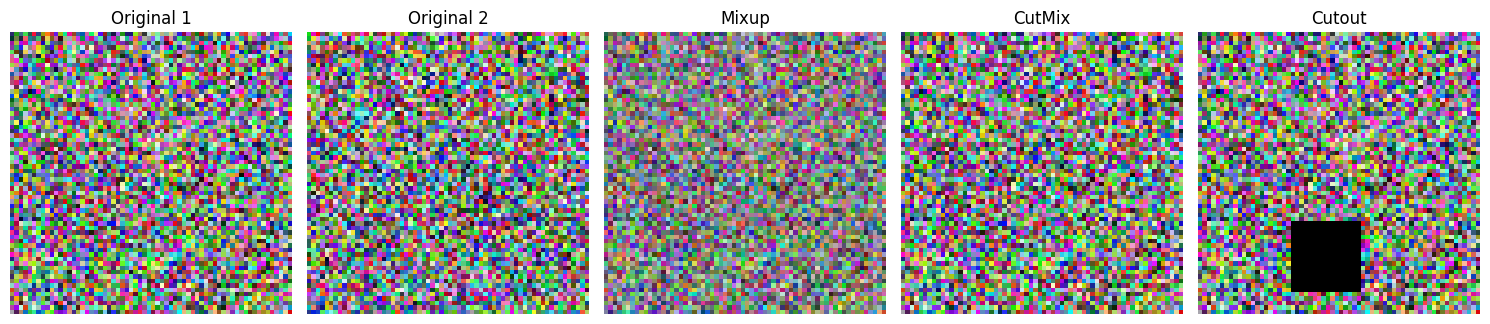

In [6]:
# Visualize original and augmented images
augmented_images = {
    "Original 1": img1,
    "Original 2": img2,
    "Mixup": mixup(img1, img2),
    "CutMix": cutmix(img1, img2),
    "Cutout": cutout(img1.clone())
}

plt.figure(figsize=(15, 4))
for i, (name, img) in enumerate(augmented_images.items()):
    plt.subplot(1, 5, i + 1)
    plt.imshow(np.transpose(img.numpy(), (1, 2, 0)))
    plt.title(name)
    plt.axis("off")
plt.tight_layout()
plt.show()


[INFO] Loading CIFAR-10 sample images...


100%|██████████| 170498071/170498071 [00:21<00:00, 7770446.91it/s] 


Extracting ./data\cifar-10-python.tar.gz to ./data
[INFO] Sample images loaded.
[INFO] Defining AutoAugment and RandAugment transformations...
[INFO] Augmentations defined.
[INFO] Applying augmentations to sample images...
[INFO] Augmentations applied.
[INFO] Visualizing original and augmented images...


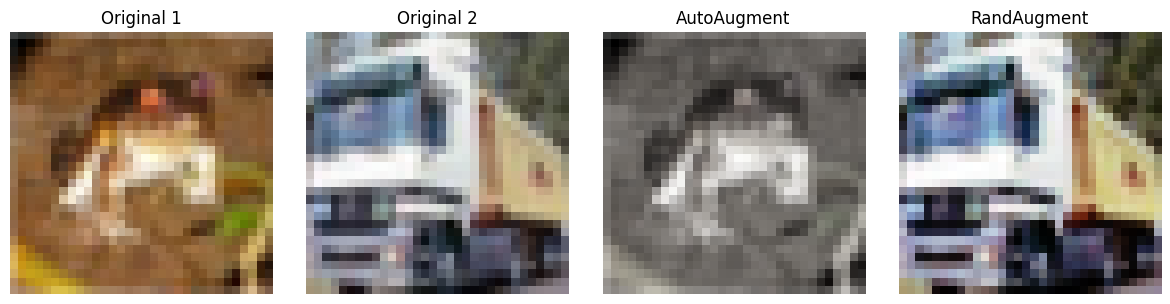

[DONE] Visual comparison complete.


In [7]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from torchvision.transforms.autoaugment import AutoAugment, AutoAugmentPolicy
from torchvision.transforms import RandAugment
from torchvision.transforms.functional import to_pil_image

# Step 1: Load CIFAR-10 dataset (only for a few samples to test)
print("[INFO] Loading CIFAR-10 sample images...")
transform_base = transforms.Compose([transforms.ToTensor()])
dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_base)

# Get two images for demonstration
image1, label1 = dataset[0]
image2, label2 = dataset[1]
print("[INFO] Sample images loaded.")

# Step 2: Define AutoAugment and RandAugment pipelines
print("[INFO] Defining AutoAugment and RandAugment transformations...")
auto_augment = transforms.Compose([
    AutoAugment(policy=AutoAugmentPolicy.CIFAR10),
    transforms.ToTensor()
])

rand_augment = transforms.Compose([
    RandAugment(num_ops=2, magnitude=9),
    transforms.ToTensor()
])
print("[INFO] Augmentations defined.")

# Step 3: Apply augmentations
print("[INFO] Applying augmentations to sample images...")
img1_pil = to_pil_image(image1)
img2_pil = to_pil_image(image2)

img1_auto = auto_augment(img1_pil)
img2_rand = rand_augment(img2_pil)
print("[INFO] Augmentations applied.")

# Step 4: Visualize results
print("[INFO] Visualizing original and augmented images...")
fig, axs = plt.subplots(1, 4, figsize=(12, 3))
axs[0].imshow(image1.permute(1, 2, 0))
axs[0].set_title("Original 1")

axs[1].imshow(image2.permute(1, 2, 0))
axs[1].set_title("Original 2")

axs[2].imshow(img1_auto.permute(1, 2, 0))
axs[2].set_title("AutoAugment")

axs[3].imshow(img2_rand.permute(1, 2, 0))
axs[3].set_title("RandAugment")

for ax in axs:
    ax.axis('off')

plt.tight_layout()
plt.show()
print("[DONE] Visual comparison complete.")
